In [ ]:
### THIS CELL SETS UP THE GOOGLE COLAB ENVIRONMENT.
### IF RUNNING THIS NOTEBOOK LOCALLY, IT MAY BE SAFELY DELETED.

try:
    import google.colab
    RUNNING_IN_COLAB = True
except ImportError:
    RUNNING_IN_COLAB = False
except Exception as e:
    raise Exception("Could not figure out if running in a colab notebook\n") from e

if RUNNING_IN_COLAB:
    !pip install dataprob

## Bayesian MCMC with emcee

This notebook demonstrates the `emcee` fitter, which samples the Bayesian posterior
distribution using an affine-invariant ensemble sampler. Multiple parallel walkers traverse
parameter space; the resulting samples directly represent the posterior distribution,
including all parameter correlations and asymmetries.

**When to use:** You want the full posterior distribution, parameters are moderately
correlated, and you do not have an analytical Jacobian available. For strongly correlated
parameters with a Jacobian, the `hmc` fitter is generally more efficient.

### Define model

We use a linear model $y = mx + b$. The same model and data are used across all fitter
notebooks so the outputs can be directly compared.

In [1]:
%matplotlib inline
import dataprob
import numpy as np

def linear_model(m=1, b=1, x=None):
    return m*x + b

### Generate noisy data

30 observations with m = 3, b = 1, and Gaussian noise (σ = 0.5).

In [2]:
true_params = {"m": 3.0, "b": 1.0}

x = np.linspace(0, 10, 30)
y_std = 0.5
y_obs = linear_model(x=x, **true_params) + np.random.normal(0, y_std, size=x.shape)

### Configure priors

Bayesian samplers require prior distributions. Setting bounds gives a uniform prior between
the bounds. Optionally, Gaussian priors can be added by setting `prior_mean` and
`prior_std` in `f.param_df`. We recommend always setting at least bounds — without them
walkers can wander into regions where the model is undefined or numerically unstable.

In [3]:
f = dataprob.setup(linear_model,
                   method="emcee",
                   non_fit_kwargs={"x": x})

# Set uniform priors via bounds
f.param_df.loc["m", "lower_bound"] = -10.0
f.param_df.loc["m", "upper_bound"] =  10.0
f.param_df.loc["b", "lower_bound"] = -10.0
f.param_df.loc["b", "upper_bound"] =  10.0

# Set guesses (emcee seeds walkers from an ML fit by default, but guesses
# are used as fallback if use_ml_guess=False)
f.param_df.loc["m", "guess"] = 1.0
f.param_df.loc["b", "guess"] = 0.0

f.param_df

,name,guess,fixed,lower_bound,upper_bound,prior_mean,prior_std
name,,,,,,,
m,m,1.0,False,-10.0,10.0,NaN,NaN
b,b,0.0,False,-10.0,10.0,NaN,NaN


### Run the sampler

`use_ml_guess=True` seeds the walker positions from an ML fit, which dramatically speeds
up burn-in. `max_convergence_cycles=3` allows the sampler to run additional steps if the
autocorrelation convergence criterion is not met after the initial `num_steps`.

In [5]:
f.fit(y_obs=y_obs,
      y_std=y_std,
      num_walkers=10,
      use_ml_guess=True,
      num_steps=1000,
      burn_in=0.1,
      num_threads=1,
      max_convergence_cycles=10,
      output_dir=None)

Running 1 of up to 10 sampler iterations
100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 988.68it/s]
  Total steps: 1000
  Mean acceptance fraction: 0.711
  Max log probability: -94.52
   Convergence not met. Est. autocorrelation time: 24.14 steps. Need ~1250 total samples.

Running 2 of up to 10 sampler iterations
100%|███████████████████████████████████████████████████████████████████████████████| 250/250 [00:00<00:00, 985.84it/s]
  Total steps: 1250
  Mean acceptance fraction: 0.712
  Max log probability: -94.52
   Converged. Autocorrelation time: 24.48 steps


Took 1250 steps (51.1x the correlation time)



### Examine fit results

`f.fit_df["estimate"]` is the mode of the posterior marginal (KDE maximum). `f.samples`
is an array of shape `(n_post_burnin_steps × n_walkers, n_params)` containing the
posterior draws. The corner plot shows the full joint posterior distribution.

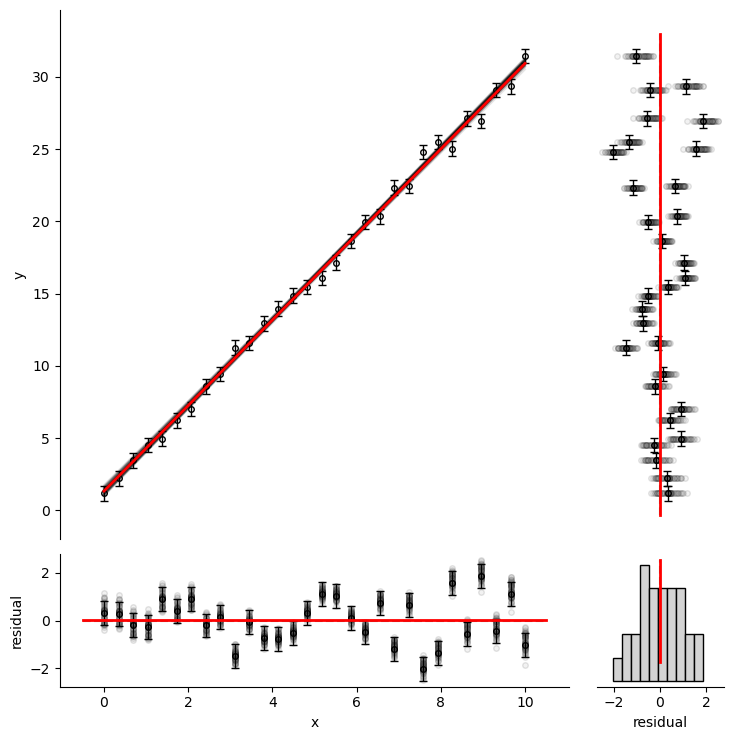

In [6]:
fig = dataprob.plot_summary(f, x_axis=x, x_label="x", y_label="y")

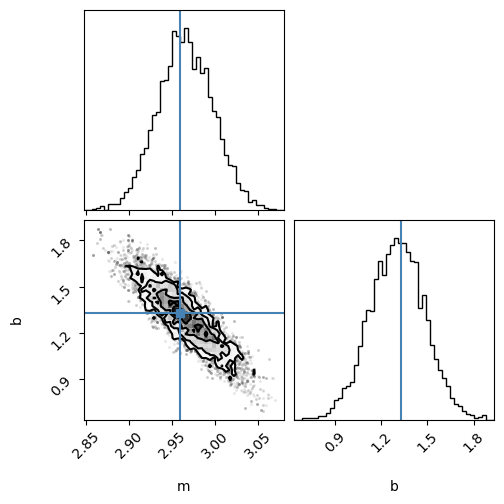

In [7]:
fig = dataprob.plot_corner(f)

In [8]:
f.fit_df

,name,estimate,std,low_95,high_95,guess,fixed,lower_bound,upper_bound,prior_mean,prior_std
name,,,,,,,,,,,
m,m,2.959441,0.032235,2.903460,3.028431,1.0,False,-10.0,10.0,NaN,NaN
b,b,1.330842,0.177982,0.948503,1.650084,0.0,False,-10.0,10.0,NaN,NaN


### Assess fit quality

`f.fit_quality["success"]` reports whether the sampler met the autocorrelation convergence
criterion ($50\tau$). If it failed, increase `num_steps` or `max_convergence_cycles`.

In [9]:
f.fit_quality

,description,is_good,value,message
name,,,,
success,fit success status,True,True,
num_obs,number of observations,True,30,
num_param,number of fit parameters,True,2,There are 28 more observations than fit parame...
lnL,log likelihood,True,-19.474439,
chi2,chi^2 goodness-of-fit,True,0.551978,A p-value of 5.520e-01 for the a goodness-of-f...
reduced_chi2,reduced chi^2,True,0.940792,A reduced chi^2 value of 0.941 is consistent w...
mean0_resid,t-test for residual mean != 0,True,0.967166,A p-value of 9.672e-01 for the one-sample t-te...
durbin-watson,Durbin-Watson test for correlated residuals,True,2.302663,A Durbin-Watson test-statistic of 2.303 is con...
ljung-box,Ljung-Box test for correlated residuals,True,0.494707,A p-value of 4.947e-01 for the Ljung-Box test ...
